In [1]:
from numpy import pi
import pint
from simulation import SimulationConfig, ExtinctionCalculator, SweepRunner
from comsol_data import parse_file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
ureg = pint.UnitRegistry()

/home/uspensky/PyProjects/Mie_SPP_Force/.venv/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
forcedir = "force_computation_results/"
scatdir = "scat_cross_sec_results/"

In [3]:
wavelen = 640
rad = 20
pmaterial = "Si"

baseConfig = SimulationConfig(
    wl=wavelen * ureg.nanometer,
    R=rad * ureg.nanometer,
    dist=1 * ureg.nanometer,
    angle=np.deg2rad(0),
    psi=pi/2,
    chi=pi/4,
    substrate='Air',
    particle=pmaterial,
    amplitude=0.1444,
    show_warnings=False,
    initial_field_type='custom',
    z_beam= 1E-12 * ureg.nanometer,
    w0=450*ureg.nanometer,
    xp=0*ureg.nanometer
)

Custom field parameters set: w0=450 nanometer, z_beam=1e-12 nanometer


## По x

### Расчеты

In [68]:
force_filename = pmaterial +"_Fx_" + str(rad) + "nm.csv"
scat_filename = pmaterial +"_sigma_x_" + str(rad) + "nm.csv"

if os.path.exists(forcedir+force_filename):
    pass
else:
    xmesh = np.linspace(-wavelen, wavelen, 40) * ureg.nanometer
    data_code, _, _ = SweepRunner(baseConfig, 'xp', xmesh, compute_force=True, compute_dipoles=False, compute_diagram=False).run()

    with open(forcedir+force_filename, 'w') as file:
        file.write('xp (m),Fx (N)\n')
        for j in range(len(xmesh)):
            file.write(str(xmesh[j].magnitude))
            file.write(',')
            file.write(str(data_code.Fx[j].magnitude))
            file.write('\n')
    
    with open(scatdir+scat_filename, 'w') as file:
        file.write('xp (m),sigma (m^2)\n')
        for j in range(len(xmesh)):
            file.write(str(xmesh[j].magnitude))
            file.write(',')
            file.write(str(data_code.sigma_tot[j]))
            file.write('\n')









100%|██████████| 40/40 [00:00<00:00, 198.33it/s]


### Графики сил

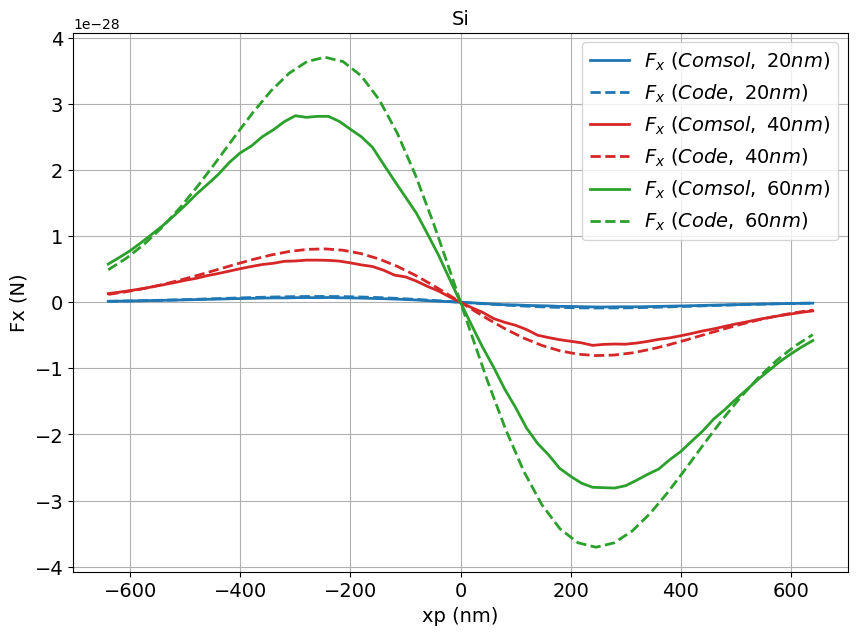

In [6]:
all_rads = [20, 40, 60]
colors = ['tab:blue', 'tab:red', 'tab:green']

f_comsol_x = parse_file("/home/uspensky/ComsolData/wl640nm_x_Si_r10-90nm_nosubs.csv")

plt.figure(figsize=(10, 7))

for a in all_rads:
    f_code_x = pd.read_csv(forcedir+pmaterial+"_Fx_" + str(a) + "nm.csv")
    i = a // 10 - 1
    j = all_rads.index(a)
    plt.plot(1E9*f_comsol_x[i]["xp (m)"], f_comsol_x[i]["Fx (N)"], label=f"$F_x\\ (Comsol,\\ {round(f_comsol_x[i]["% r (m)"].iloc[0]*1E9)} nm)$", c=colors[j], lw=2)
    plt.plot(f_code_x["xp (m)"], f_code_x["Fx (N)"], label=f'$F_x\\ (Code,\\ {a} nm)$', c=colors[j], linestyle='--', lw=2)

    
plt.xlabel("xp (nm)", fontsize=14)
plt.ylabel("Fx (N)", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc='upper right')
plt.grid()
plt.title(pmaterial, fontsize=14)
plt.savefig('/home/uspensky/Изображения/forces_plots/Si_fx_r20_40_60nm.png', dpi=200)

## По z

### Расчеты

In [ ]:
force_filename =  pmaterial + "_Fz_" + str(rad)+"nm.csv"
scat_filename = pmaterial +"_sigma_z_" + str(rad) + "nm.csv"

if os.path.exists(forcedir+force_filename):
    pass
else:
    fmesh = np.linspace(-2*wavelen, wavelen, 40) * ureg.nanometer
    data_code, _, _ = SweepRunner(baseConfig, 'z_beam', fmesh, compute_force=True, compute_dipoles=False, compute_diagram=False).run()

    with open(forcedir+force_filename, 'w') as file:
        file.write('f (m),Fz (N)\n')
        for j in range(len(fmesh)):
            file.write(str(fmesh[j].magnitude))
            file.write(',')
            file.write(str(data_code.Fz[j].magnitude))
            file.write('\n')
        
    with open(scatdir+scat_filename, 'w') as file:
        file.write('f (m),sigma (m^2)\n')
        for j in range(len(fmesh)):
            file.write(str(fmesh[j].magnitude))
            file.write(',')
            file.write(str(data_code.sigma_tot[j]))
            file.write('\n')

### Графики сил

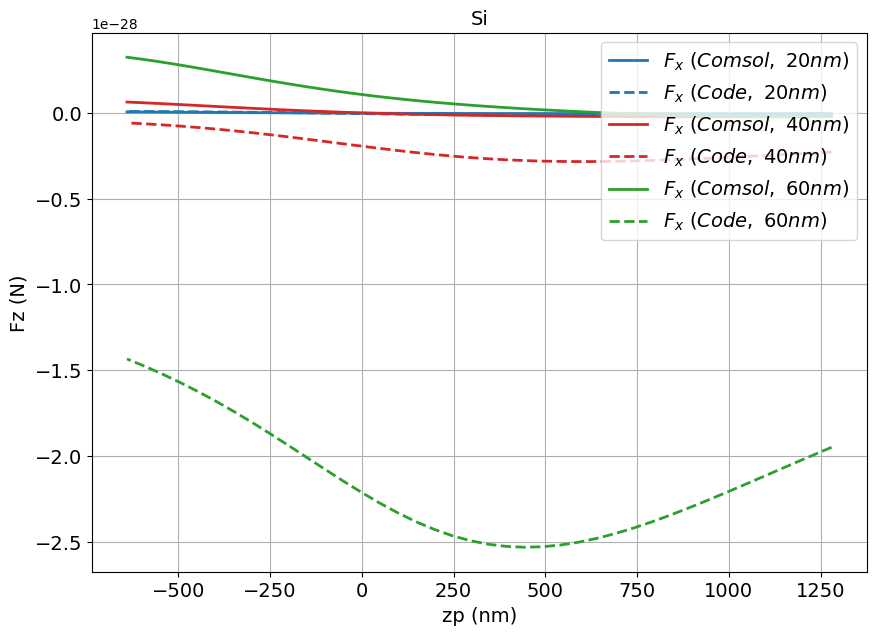

In [79]:
all_rads = [20, 40, 60]
colors = ['tab:blue', 'tab:red', 'tab:green']

f_comsol_z = parse_file("/home/uspensky/ComsolData/wl640nm_z_SiO2_r10-60nm_nosubs.csv")

plt.figure(figsize=(10, 7))

for a in all_rads:
    f_code_z = pd.read_csv(forcedir+pmaterial+"_Fz_" + str(a) + "nm.csv")
    i = a // 10 - 1
    j = all_rads.index(a)
    plt.plot(-1E9*f_comsol_z[i]["f (m)"], f_comsol_z[i]["Fz (N)"], label=f"$F_x\\ (Comsol,\\ {round(f_comsol_z[i]["% r (m)"].iloc[0]*1E9)} nm)$", c=colors[j], lw=2)
    plt.plot(-f_code_z["f (m)"], f_code_z["Fz (N)"], label=f'$F_x\\ (Code,\\ {a} nm)$', c=colors[j], linestyle='--', lw=2)

    
plt.xlabel("zp (nm)", fontsize=14)
plt.ylabel("Fz (N)", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc='upper right')
plt.grid()
plt.title(pmaterial, fontsize=14)
plt.savefig('/home/uspensky/Изображения/forces_plots/Si_fz_r20_40_60nm.png', dpi=200)

## Проверка движения частицы

In [5]:
zmesh = np.linspace(-wavelen, wavelen, 40) * ureg.nanometer
data_code, _, _ = SweepRunner(baseConfig, 'dist', zmesh, compute_force=True, compute_dipoles=False, compute_diagram=False).run()

plt.plot(zmesh, data_code.Fz)


  0%|          | 0/40 [00:00<?, ?it/s]/home/uspensky/PyProjects/Mie_SPP_Force/green_func_v2.py:84: RuntimeWarning: overflow encountered in exp
  def exp_fac(kr): return exp(1j*kz(kr)*h)
/home/uspensky/PyProjects/Mie_SPP_Force/green_func_v2.py:87: RuntimeWarning: invalid value encountered in scalar multiply
  lambda kr: rp(kr) * kr*k*kz(kr)*exp_fac(kr)*j0(kr*k*r),   # 0
/home/uspensky/PyProjects/Mie_SPP_Force/green_func_v2.py:84: RuntimeWarning: overflow encountered in exp
  def exp_fac(kr): return exp(1j*kz(kr)*h)
/home/uspensky/PyProjects/Mie_SPP_Force/green_func_v2.py:87: RuntimeWarning: invalid value encountered in scalar multiply
  lambda kr: rp(kr) * kr*k*kz(kr)*exp_fac(kr)*j0(kr*k*r),   # 0
/home/uspensky/PyProjects/Mie_SPP_Force/green_func_v2.py:84: RuntimeWarning: overflow encountered in exp
  def exp_fac(kr): return exp(1j*kz(kr)*h)
/home/uspensky/PyProjects/Mie_SPP_Force/green_func_v2.py:87: RuntimeWarning: invalid value encountered in scalar multiply
  lambda kr: rp(kr) * kr

KeyboardInterrupt: 

  0%|          | 0/40 [00:03<?, ?it/s]


## Сечения рассеяния

Text(0.5, 1.0, 'SiO2, 10nm, z')

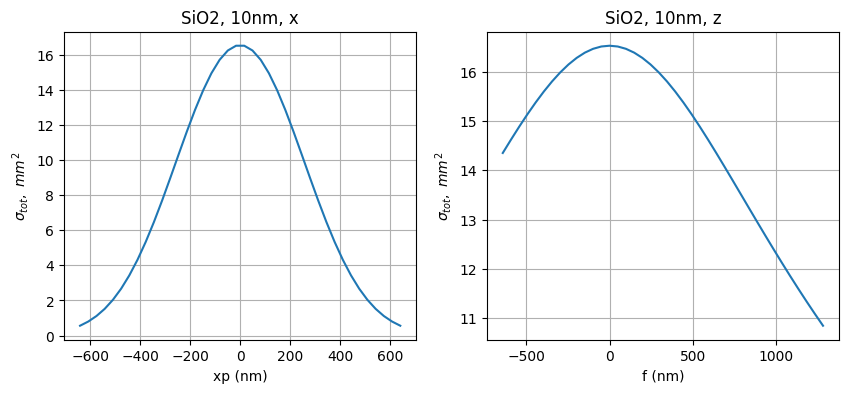

In [96]:
a = 10
m = 'SiO2'
sigmax = pd.read_csv(scatdir+m+"_sigma_x_"+ str(a) + "nm.csv")
sigmaz = pd.read_csv(scatdir+m+"_sigma_z_"+ str(a) + "nm.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(sigmax['xp (nm)'], 1e6*sigmax['sigma (m^2)'])
ax1.set_xlabel('xp (nm)')
ax1.set_ylabel('$\\sigma_{tot},\\ mm^2$')
ax1.grid()
ax1.set_title(m + ", " + str(a)+"nm, x")

ax2.plot(-sigmaz['f (nm)'], 1e6*sigmaz['sigma (m^2)'])
ax2.set_xlabel('f (nm)')
ax2.set_ylabel('$\\sigma_{tot},\\ mm^2$')
ax2.grid()
ax2.set_title(m + ", " + str(a)+"nm, z")